## Resumen de mediciones por grupo seleccionado

Retoma el resultado de `selecciones_de_estaciones.ipynb`: leemos los geojson ya guardados (`oan_gems_seleccion.geojson` y `oan_gems_no_seleccion.geojson`) y mostramos, de forma explícita, cuántas mediciones tiene cada zona nombrada (`grupo_nombre`).

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA = Path("../data")

seleccionados = gpd.read_file(DATA / "oan_gems_seleccion.geojson")
no_seleccionados = gpd.read_file(DATA / "oan_gems_no_seleccion.geojson")

print(seleccionados.shape, no_seleccionados.shape)

(3902, 12) (2612, 14)


### Mediciones por zona seleccionada

`seleccionados` ya trae la columna `grupo_nombre` asignada en `selecciones_de_estaciones.ipynb` (LDS, RN-UPM2, RN-UPM1, RDP-MONTES). Agrupamos y contamos.

In [3]:
resumen_seleccionados = (
    seleccionados.groupby("grupo_nombre")
    .agg(mediciones=("chla", "count"))
    .sort_values("mediciones", ascending=False)
)
resumen_seleccionados["% del seleccionado"] = (
    resumen_seleccionados["mediciones"] / seleccionados.shape[0] * 100
).round(1)
resumen_seleccionados

,mediciones,% del seleccionado
grupo_nombre,,
RN-UPM2,1693,43.4
LDS,1336,34.2
RN-UPM1,477,12.2
RDP-MONTES,396,10.1


### Seleccionados vs. no seleccionados

Juntamos ambos archivos para ver la proporción de cada zona sobre el total del dataset limpio (`oan_gems_clean.geojson`, 6514 mediciones).

In [4]:
todo = pd.concat(
    [seleccionados[["grupo_nombre", "chla"]], no_seleccionados[["grupo_nombre", "chla"]]],
    ignore_index=True,
)

resumen_total = (
    todo.groupby("grupo_nombre")
    .agg(mediciones=("chla", "count"))
    .sort_values("mediciones", ascending=False)
)
resumen_total["% del total"] = (resumen_total["mediciones"] / todo.shape[0] * 100).round(1)
resumen_total

,mediciones,% del total
grupo_nombre,,
NO-SELECCIONADO,2612,40.1
RN-UPM2,1693,26.0
LDS,1336,20.5
RN-UPM1,477,7.3
RDP-MONTES,396,6.1


### Gráfico: mediciones por zona seleccionada

Solo las 4 zonas que forman el dataset principal (sin `NO-SELECCIONADO`).

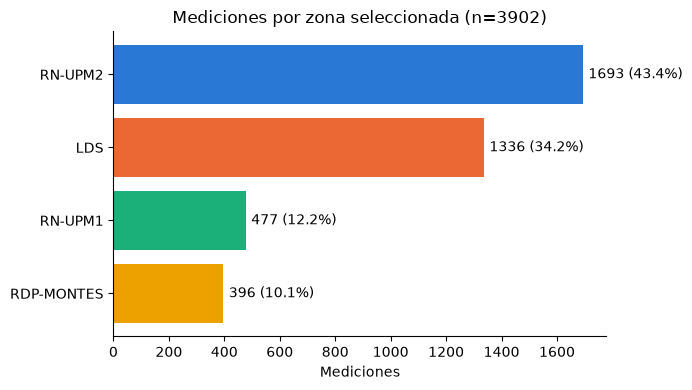

In [5]:
colores = {
    "RN-UPM2": "#2a78d6",
    "LDS": "#eb6834",
    "RN-UPM1": "#1baf7a",
    "RDP-MONTES": "#eda100",
}

orden = resumen_seleccionados.index.tolist()
valores = resumen_seleccionados["mediciones"].values
barras = [colores[g] for g in orden]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(orden, valores, color=barras)
ax.bar_label(bars, labels=[f"{v} ({p}%)" for v, p in zip(valores, resumen_seleccionados['% del seleccionado'])], padding=4)
ax.invert_yaxis()
ax.set_xlabel("Mediciones")
ax.set_title("Mediciones por zona seleccionada (n=3902)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Gráfico: zonas seleccionadas vs. resto del dataset

Mismo grupo_nombre, pero incluyendo `NO-SELECCIONADO` para ver la proporción sobre el total de mediciones limpias (6514).

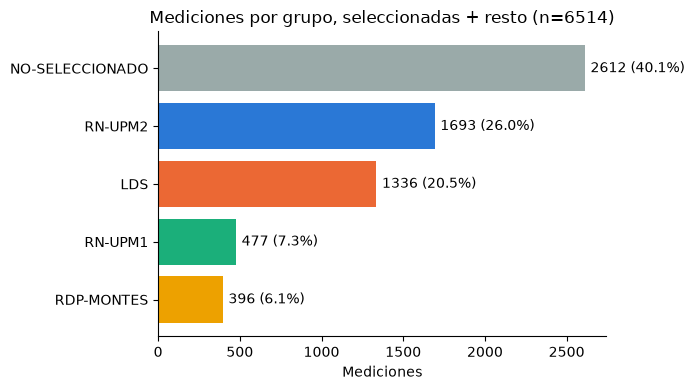

In [6]:
colores_total = dict(colores)
colores_total["NO-SELECCIONADO"] = "#9AAAA9"

orden_total = resumen_total.index.tolist()
valores_total = resumen_total["mediciones"].values
barras_total = [colores_total[g] for g in orden_total]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(orden_total, valores_total, color=barras_total)
ax.bar_label(bars, labels=[f"{v} ({p}%)" for v, p in zip(valores_total, resumen_total['% del total'])], padding=4)
ax.invert_yaxis()
ax.set_xlabel("Mediciones")
ax.set_title("Mediciones por grupo, seleccionadas + resto (n=6514)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()